In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import bambi as bmb
import matplotlib.pyplot as plt
from s0_fun_base import XY_sur_compu, XY_grw_f_compu, XY_grw_nf_compu, XY_fec_compu, XY_flow_compu, XY_grw_compu
from s0_fun_IPMs import IPM_listk, kernel_setting, IPM_listk_glmmcmc
import statsmodels.api as sm
import statsmodels.formula.api as smf
import gpflow
# simulating true populations
from s0_fun_IBMs import IBM_1step_glm_mle, IBM_1step_gp, popu_structure

In [2]:
popu_whole = pickle.load(open(file = os.getcwd()+f"/true_popu/popu_whole.pkl", mode="rb"))
X_sur, y_sur = XY_sur_compu(popu_whole)
X_fec, y_fec = XY_fec_compu(popu_whole)
X_flow, y_flow = XY_flow_compu(popu_whole)
X_grw_f, y_grw_f = XY_grw_f_compu(popu_whole)
X_grw_nf, y_grw_nf = XY_grw_nf_compu(popu_whole)
glm_mle_true_models = pickle.load(open(file = os.getcwd()+f"/true_popu/glm_mle_true_models.pkl", mode="rb"))

In [3]:
np.random.seed(9612797)
glm_mle_true_population_big = popu_whole.copy()
for _ in range(70):
    z = popu_structure(glm_mle_true_population_big) 
    glm_mle_true_population_big = IBM_1step_glm_mle(zt=z[0], age=z[1], models=glm_mle_true_models) 


In [4]:
glm_mle_true_population_big

,size,sizeNext,fec,flow,surv,age,ageNext
0,2.847102,3.397918,1.0,4.0,1.0,13.0,13.0
1,3.684623,NaN,1.0,8.0,0.0,13.0,NaN
2,3.727325,NaN,1.0,4.0,0.0,13.0,NaN
3,3.171911,3.214913,1.0,5.0,1.0,13.0,13.0
4,3.219174,3.567564,1.0,8.0,1.0,13.0,13.0
...,...,...,...,...,...,...,...
4546,NaN,0.390111,NaN,NaN,NaN,NaN,1.0
4547,NaN,0.025171,NaN,NaN,NaN,NaN,1.0
4548,NaN,0.149435,NaN,NaN,NaN,NaN,1.0
4549,NaN,0.097656,NaN,NaN,NaN,NaN,1.0


In [5]:
re_MCMC=True

In [6]:
if re_MCMC == True:
    # MCMC for GLMs
    # for the 1st datastes glm_mle_true_population_big with sep setting (seprate models for breeders and non-breeders).
    # grw_f
    df_grw_f = XY_grw_f_compu(glm_mle_true_population_big)
    model_grw_f = bmb.Model("sizeNext ~ size", pd.concat(df_grw_f, axis=1))
    trace_grw_f = model_grw_f.fit(draws=5000, tune=10000, discard_tuned_samples=True, chains=1, progressbar=False)
    pickle.dump(trace_grw_f, open(file = os.getcwd()+f"/true_popu/glm_mle_true_population_big/trace_grw_f_big.pkl", mode="wb"))

    # grw_nf
    df_grw_nf = XY_grw_nf_compu(glm_mle_true_population_big)
    model_grw_nf = bmb.Model("sizeNext ~ size", pd.concat(df_grw_nf, axis=1))
    trace_grw_nf = model_grw_nf.fit(draws=5000, tune=10000, discard_tuned_samples=True, chains=1, progressbar=False)
    pickle.dump(trace_grw_nf, open(file = os.getcwd()+f"/true_popu/glm_mle_true_population_big/trace_grw_nf_big.pkl", mode="wb"))

    # sur
    df_sur = XY_sur_compu(glm_mle_true_population_big)
    model_sur = bmb.Model("sur ~ size", pd.concat(df_sur, axis=1), family='bernoulli')
    trace_sur = model_sur.fit(draws=5000, tune=10000, discard_tuned_samples=True, chains=1, progressbar=False)
    pickle.dump(trace_sur, open(file = os.getcwd()+f"/true_popu/glm_mle_true_population_big/trace_sur_big.pkl", mode="wb"))

    # fec
    df_fec = XY_fec_compu(glm_mle_true_population_big)
    model_fec = bmb.Model("fec ~ size", pd.concat(df_fec, axis=1), family='bernoulli')
    trace_fec = model_fec.fit(draws=5000, tune=10000, discard_tuned_samples=True, chains=1, progressbar=False)
    pickle.dump(trace_fec, open(file = os.getcwd()+f"/true_popu/glm_mle_true_population_big/trace_fec_big.pkl", mode="wb"))

    # flow
    df_flow = XY_flow_compu(glm_mle_true_population_big)
    model_flow = bmb.Model("flow ~ size", pd.concat(df_flow, axis=1), family='poisson')
    trace_flow = model_flow.fit(draws=5000, tune=10000, discard_tuned_samples=True, chains=1, progressbar=False)
    pickle.dump(trace_flow, open(file = os.getcwd()+f"/true_popu/glm_mle_true_population_big/trace_flow_big.pkl", mode="wb"))


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [sizeNext_sigma, Intercept, size]
Sampling 1 chain for 10_000 tune and 5_000 draw iterations (10_000 + 5_000 draws total) took 4 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [sizeNext_sigma, Intercept, size]
Sampling 1 chain for 10_000 tune and 5_000 draw iterations (10_000 + 5_000 draws total) took 4 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks
Modeling the probability that sur==1
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [Intercept, size]
Sampling 1 chain for 10_000 tune and 5_000 draw iterations (10_000 + 5_000 draws total) took 7 seconds.
Only one chain was sampled, thi

In [7]:
# IPM Mesh setting
lower_p = 0
upper_p = 5
m_size_p = 50
mesh_setting = kernel_setting(m_size_p, lower_p, upper_p)
Xp = mesh_setting[0]
step_size = m_size_p // 5
ticks = [i * step_size for i in range(0, 6)]
ticks[-1] = m_size_p - 1

# IPMs for true models
true_p_glm, true_f_glm = IPM_listk(mesh_setting=mesh_setting, models=glm_mle_true_models, grw_setting='sep')
# lambdas
true_lambda_glm = np.linalg.eig(true_p_glm+true_f_glm)[0][0]
 # eigenvects
true_repro_glm = np.linalg.eig(true_p_glm.T+true_f_glm.T)[1][:,0].real/np.linalg.eig(true_p_glm.T+true_f_glm.T)[1][:,0].real[0]
true_stable_glm = np.linalg.eig(true_p_glm+true_f_glm)[1][:,0].real/np.sum(np.linalg.eig(true_p_glm+true_f_glm)[1][:,0].real)
true_stable_rep_glm = true_stable_glm * glm_mle_true_models["m_fec"].predict(pd.DataFrame(Xp, columns=['size'])).values
true_stable_rep_glm = true_stable_rep_glm/np.sum(true_stable_rep_glm)

In [8]:
re_ipm = True

In [13]:
if re_ipm == True:
    # Loading GLM MCMCs for glm_mle_true_population_big datasets

    trace = {}
    trace['trace_grw_f'] = pickle.load(open(file = os.getcwd()+f"/true_popu/glm_mle_true_population_big/trace_grw_f_big.pkl", mode="rb"))
    trace['trace_grw_nf'] = pickle.load(open(file = os.getcwd()+f"/true_popu/glm_mle_true_population_big/trace_grw_nf_big.pkl", mode="rb"))
    trace['trace_fec'] = pickle.load(open(file = os.getcwd()+f"/true_popu/glm_mle_true_population_big/trace_fec_big.pkl", mode="rb"))
    trace['trace_flow'] = pickle.load(open(file = os.getcwd()+f"/true_popu/glm_mle_true_population_big/trace_flow_big.pkl", mode="rb"))
    trace['trace_sur'] = pickle.load(open(file = os.getcwd()+f"/true_popu/glm_mle_true_population_big/trace_sur_big.pkl", mode="rb"))

    model = {}
    df_grw_f = XY_grw_f_compu(glm_mle_true_population_big)
    model['m_grw_f'] = bmb.Model("sizeNext ~ size", pd.concat(df_grw_f, axis=1))
    # grw_nf
    df_grw_nf = XY_grw_nf_compu(glm_mle_true_population_big)
    model['m_grw_nf'] = bmb.Model("sizeNext ~ size", pd.concat(df_grw_nf, axis=1))
    # sur
    df_sur = XY_sur_compu(glm_mle_true_population_big)
    model['m_sur'] = bmb.Model("sur ~ size", pd.concat(df_sur, axis=1), family='bernoulli')
    # fec
    df_fec = XY_fec_compu(glm_mle_true_population_big)
    model['m_fec'] = bmb.Model("fec ~ size", pd.concat(df_fec, axis=1), family='bernoulli')
    # flow
    df_flow = XY_flow_compu(glm_mle_true_population_big)
    model['m_flow_poi'] = bmb.Model("flow ~ size", pd.concat(df_flow, axis=1), family='poisson')
    # recru
    model['recruit_p'] = glm_mle_true_models['recruit_p']
    model['alpha'] = glm_mle_true_models['alpha']
    model['beta'] = glm_mle_true_models['beta']

    np.random.seed(1234567)
    index = {}; diff_p = {}; diff_f = {}; growth_rate={}; stable = {}; repro = {}; stable_rep = {}
    for i in range(5000):
        c_index = np.random.randint(low=0, high=[5000, 5000, 5000, 5000, 5000], size=5)
        c_p, c_f = IPM_listk_glmmcmc(mesh_setting=mesh_setting, models=model, 
                                    traces=trace, index=c_index, grw_setting='sep')
        index[i] = c_index
        diff_p[i] = c_p - true_p_glm
        diff_f[i] = c_f - true_f_glm
        eig1 = np.linalg.eig(c_p+c_f)
        eigT = np.linalg.eig(c_p.T+c_f.T) 
        growth_rate[i] = eig1[0][0]
        stable[i] = eig1[1][:,0].real/np.sum(eig1[1][:,0].real)
        repro[i] = eigT[1][:,0].real; del(eig1); del(eigT)
        stable_rep[i] = stable[i] * model["m_fec"].predict(trace["trace_fec"], data=pd.DataFrame(Xp, columns=['size']), inplace=False).posterior['fec_mean'].values[0][c_index[0], : ]
        stable_rep[i] = stable_rep[i]/np.sum(stable_rep[i])

In [10]:
from matplotlib.ticker import MaxNLocator
import seaborn as sns

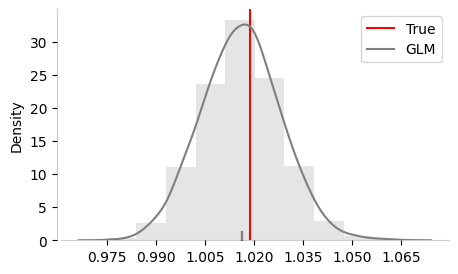

In [30]:
fig = plt.figure(figsize=(5, 3))

ax = fig.add_subplot(1, 1, 1)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
# plt.title('$D_{glm}$',fontsize=15)
plt.hist(np.array(list(growth_rate.values())).real, alpha=0.2, density=True, color='C7')
plt.axvline(true_lambda_glm.real, color='red', label='True')
sns.kdeplot(np.array(list(growth_rate.values())).real, color='C7', label='GLM', bw_adjust=1.3)
plt.plot(np.mean(np.array(list(growth_rate.values())).real), 0.3, marker='$|$',color='C7', markersize=10)
plt.legend()
# plt.savefig('plot_glm_big.pdf')  